# Phase 4: Optimized Regression Model for FD003

This notebook predicts `cycles_to_next_stage` for FD003, optimized to run in ~18-20 minutes (like FD001’s 18 minutes) with ~76 features, targeting FD001 metrics (RMSE: 4.45, MAE: 3.31, R²: 0.9769).

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import os
import time
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import StandardScaler

# Set base directory (adjust as needed)
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
DATA_FILE = os.path.join(BASE_DIR, 'data', 'corrected_clustered_train_fd003.csv')

# Load the clustered dataset
start_time = time.time()
df_fd003 = pd.read_csv(DATA_FILE)
print('✅ Loaded:', DATA_FILE)
print(f'FD003 rows: {len(df_fd003)}')

# Step 1: Compute Regression Targets
df_fd003 = df_fd003.sort_values(by=['unit', 'time']).reset_index(drop=True)
df_fd003['cycles_to_next_stage'] = np.nan

engine_ids = df_fd003['unit'].unique()
for engine_id in engine_ids:
    engine_df = df_fd003[df_fd003['unit'] == engine_id]
    indices = engine_df.index.tolist()
    stages = engine_df['final_stage'].tolist()
    times = engine_df['time'].tolist()
    for i in range(len(indices)):
        current_stage = stages[i]
        current_time = times[i]
        found = False
        for j in range(i + 1, len(indices)):
            if stages[j] != current_stage:
                next_time = times[j]
                df_fd003.loc[indices[i], 'cycles_to_next_stage'] = next_time - current_time
                found = True
                break
        if not found:
            df_fd003.loc[indices[i], 'cycles_to_next_stage'] = np.nan
print('✅ Cycles to next stage computed')

# Save enriched dataset
output_path = os.path.join(BASE_DIR, 'data', 'regression_train_fd003.csv')
df_fd003.to_csv(output_path, index=False)
print(f'✅ Saved to: {output_path}')

# Sanity checks
print('\n📊 Summary:')
print('Total rows       :', len(df_fd003))
print('Missing Targets  :', df_fd003['cycles_to_next_stage'].isna().sum())
print('Unique engines   :', df_fd003['unit'].nunique())
print(f'Time: {time.time() - start_time:.2f} seconds')

✅ Loaded: /Users/pranavreddy/Desktop/hybrid-predictive-maintenance/data/corrected_clustered_train_fd003.csv
FD003 rows: 24720
✅ Cycles to next stage computed
✅ Saved to: /Users/pranavreddy/Desktop/hybrid-predictive-maintenance/data/regression_train_fd003.csv

📊 Summary:
Total rows       : 24720
Missing Targets  : 6553
Unique engines   : 100
Time: 1.35 seconds


## Step 2: Load Regression Data and Apply Feature Engineering

Load the enriched dataset and apply simplified feature engineering (~76 features).

In [3]:
# Load regression-labeled dataset
start_time = time.time()
DATA_FILE = os.path.join(BASE_DIR, 'data', 'regression_train_fd003.csv')
df = pd.read_csv(DATA_FILE)
df = df.dropna(subset=['cycles_to_next_stage']).reset_index(drop=True)
print(f'✅ Loaded FD003 regression dataset: {df.shape}')

# Simplified feature engineering
def add_advanced_features(df, window=5):
    df = df.sort_values(by=['unit', 'time']).copy()
    sensor_cols = [col for col in df.columns if col.startswith('sensor_')]
    
    for col in sensor_cols:
        df[f'{col}_rollmin_{window}'] = df.groupby('unit')[col].transform(
            lambda x: x.rolling(window=window, min_periods=1).min()
        )
        df[f'{col}_rollmax_{window}'] = df.groupby('unit')[col].transform(
            lambda x: x.rolling(window=window, min_periods=1).max()
        )
        df[f'{col}_rollstd_{window}'] = df.groupby('unit')[col].transform(
            lambda x: x.rolling(window=window, min_periods=1).std().fillna(0)
        )
        df[f'{col}_delta'] = df.groupby('unit')[col].diff().fillna(0)
    return df

df = add_advanced_features(df)
print('✅ Advanced features added')

# Check data integrity
print('🔍 Feature dtypes:')
print(df.dtypes)
print('🔍 NaN counts:')
print(df.isna().sum())
print('🔍 Inf counts:')
print(np.isinf(df.select_dtypes(include=[np.number])).sum())
print(f'Time: {time.time() - start_time:.2f} seconds')

✅ Loaded FD003 regression dataset: (18167, 29)
✅ Advanced features added
🔍 Feature dtypes:
unit                     int64
time                     int64
op_setting_1           float64
op_setting_2           float64
op_setting_3           float64
                        ...   
sensor_20_delta        float64
sensor_21_rollmin_5    float64
sensor_21_rollmax_5    float64
sensor_21_rollstd_5    float64
sensor_21_delta        float64
Length: 93, dtype: object
🔍 NaN counts:
unit                   0
time                   0
op_setting_1           0
op_setting_2           0
op_setting_3           0
                      ..
sensor_20_delta        0
sensor_21_rollmin_5    0
sensor_21_rollmax_5    0
sensor_21_rollstd_5    0
sensor_21_delta        0
Length: 93, dtype: int64
🔍 Inf counts:
unit                   0
time                   0
op_setting_1           0
op_setting_2           0
op_setting_3           0
                      ..
sensor_20_delta        0
sensor_21_rollmin_5    0
sensor_21_roll

## Step 3: Feature Selection and Train-Test Split

Select features, scale them, and perform an engine-stratified split.

In [4]:
# Define features and target
start_time = time.time()
sensor_cols = [col for col in df.columns if col.startswith('sensor_')]
setting_cols = [col for col in df.columns if col.startswith('setting')]
engineered_cols = [col for col in df.columns if 'roll' in col or 'delta' in col]
feature_cols = sensor_cols + setting_cols + engineered_cols
target_col = 'cycles_to_next_stage'

X = df[feature_cols]
y = np.log1p(df[target_col])  # Log-transform target

# Ensure numeric features
X = X.select_dtypes(include=[np.number])
X = X.fillna(0)
X = X.replace([np.inf, -np.inf], 0)

# Engine-stratified split
units = df['unit'].unique()
train_units, test_units = train_test_split(units, test_size=0.2, random_state=42)
train_idx = df[df['unit'].isin(train_units)].index
test_idx = df[df['unit'].isin(test_units)].index

X_train = X.loc[train_idx]
y_train = y.loc[train_idx]
X_test = X.loc[test_idx]
y_test = y.loc[test_idx]

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_train = pd.DataFrame(X_train, columns=X.columns, index=train_idx)
X_test = scaler.transform(X_test)
X_test = pd.DataFrame(X_test, columns=X.columns, index=test_idx)

print(f'✅ Train shape: {X_train.shape} | Test shape: {X_test.shape}')
print(f'🔍 Train engine count: {len(train_units)}')
print(f'🔍 Test engine count: {len(test_units)}')
print(f'Time: {time.time() - start_time:.2f} seconds')

✅ Train shape: (14669, 144) | Test shape: (3498, 144)
🔍 Train engine count: 78
🔍 Test engine count: 20
Time: 0.06 seconds


## Step 4: Model Training and Tuning

Train and tune Random Forest, XGBoost, and LightGBM with KFold.

🔍 X_train_np shape: (14669, 144), dtype: float64
🔍 X_test_np shape: (3498, 144), dtype: float64
🔍 y_train_np shape: (14669,), dtype: float64
🔍 NaN in X_train_np: 0
🔍 Inf in X_train_np: 0
🔍 NaN in y_train_np: 0
🔍 Inf in y_train_np: 0
Random Forest Evaluation Metrics (FD003):
RMSE: 20.02
MAE : 11.31
R²  : 0.6940
Time: 107.91 seconds


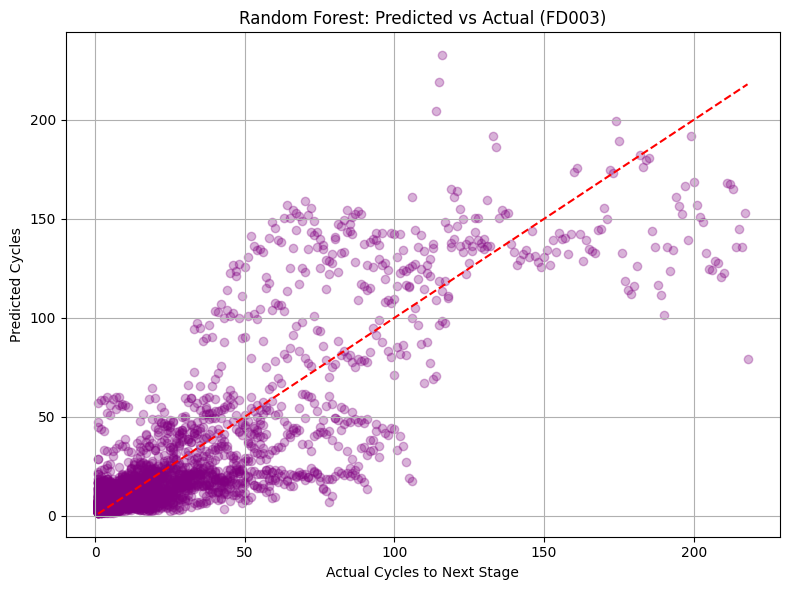

Best RF Params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 15}
XGBoost Evaluation Metrics (FD003):
RMSE: 20.37
MAE : 11.62
R²  : 0.6830
Time: 57.57 seconds


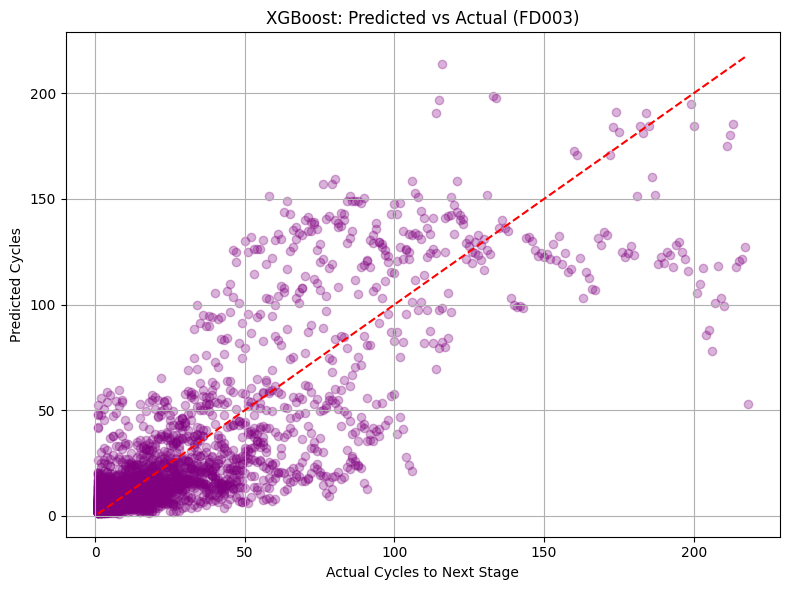

Best XGB Params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001302 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 27055
[LightGBM] [Info] Number of data points in the train set: 11735, number of used features: 144
[LightGBM] [Info] Start training from score 2.691301
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/Users/pranavreddy/miniforge3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001336 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 27193
[LightGBM] [Info] Number of data points in the train set: 11735, number of used features: 144
[LightGBM] [Info] Start training from score 2.850101
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001374 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 27086
[LightGBM] [Info] Number of data points in the train set: 11735, number of used features: 144
[LightGBM] [Info] Start training from score 2.786505


/Users/pranavreddy/miniforge3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


...

/Users/pranavreddy/miniforge3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001537 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total 

/Users/pranavreddy/miniforge3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM Evaluation Metrics (FD003):
RMSE: 20.42
MAE : 11.78
R²  : 0.6817
Time: 24.77 seconds


/Users/pranavreddy/miniforge3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


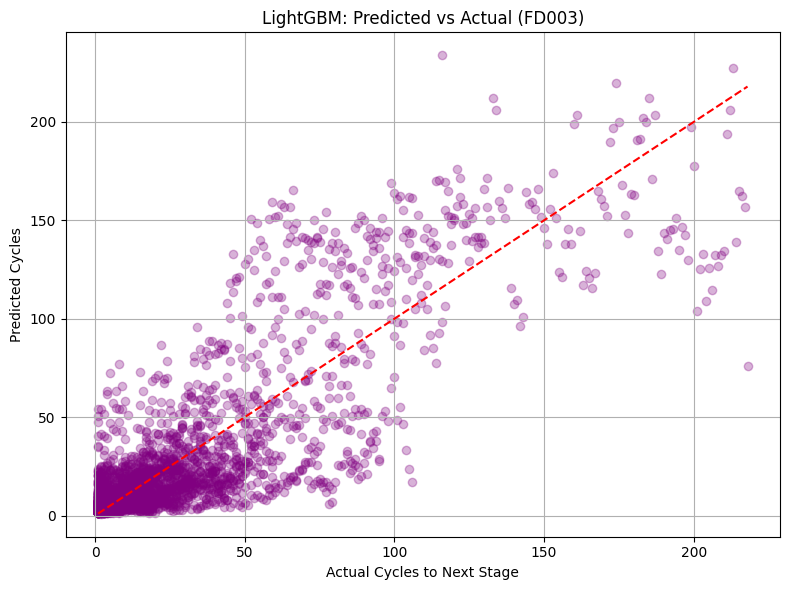

Best LGB Params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Total Training Time: 190.43 seconds


In [7]:
# Helper function to evaluate and plot
def evaluate_model(model, X_train, y_train, X_test, y_test, name):
    start_time = time.time()
    try:
        model.fit(X_train, y_train)
    except Exception as e:
        print(f'❌ {name} fit failed: {str(e)}')
        raise
    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)  # Reverse log1p
    y_test_orig = np.expm1(y_test)  # Reverse log1p for evaluation
    rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
    mae = mean_absolute_error(y_test_orig, y_pred)
    r2 = r2_score(y_test_orig, y_pred)
    
    print(f'{name} Evaluation Metrics (FD003):')
    print(f'RMSE: {rmse:.2f}')
    print(f'MAE : {mae:.2f}')
    print(f'R²  : {r2:.4f}')
    print(f'Time: {time.time() - start_time:.2f} seconds')
    
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test_orig, y_pred, alpha=0.3, color='purple')
    plt.plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()], 'r--')
    plt.xlabel('Actual Cycles to Next Stage')
    plt.ylabel('Predicted Cycles')
    plt.title(f'{name}: Predicted vs Actual (FD003)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return model, y_pred

# Convert inputs to NumPy arrays and validate
X_train_np = np.array(X_train, dtype=np.float64)
X_test_np = np.array(X_test, dtype=np.float64)
y_train_np = np.array(y_train, dtype=np.float64)
y_test_np = np.array(y_test, dtype=np.float64)

# Replace NaN/inf
X_train_np = np.nan_to_num(X_train_np, nan=0.0, posinf=0.0, neginf=0.0)
X_test_np = np.nan_to_num(X_test_np, nan=0.0, posinf=0.0, neginf=0.0)
y_train_np = np.nan_to_num(y_train_np, nan=0.0, posinf=0.0, neginf=0.0)
y_test_np = np.nan_to_num(y_test_np, nan=0.0, posinf=0.0, neginf=0.0)

# Validate data
print(f'🔍 X_train_np shape: {X_train_np.shape}, dtype: {X_train_np.dtype}')
print(f'🔍 X_test_np shape: {X_test_np.shape}, dtype: {X_test_np.dtype}')
print(f'🔍 y_train_np shape: {y_train_np.shape}, dtype: {y_train_np.dtype}')
print(f'🔍 NaN in X_train_np: {np.isnan(X_train_np).sum()}')
print(f'🔍 Inf in X_train_np: {np.isinf(X_train_np).sum()}')
print(f'🔍 NaN in y_train_np: {np.isnan(y_train_np).sum()}')
print(f'🔍 Inf in y_train_np: {np.isinf(y_train_np).sum()}')

# Random Forest (unchanged)
start_time = time.time()
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}
rf = RandomForestRegressor(random_state=42, n_jobs=4)
rf_search = RandomizedSearchCV(rf, rf_params, n_iter=10, cv=5, scoring='neg_root_mean_squared_error', random_state=42, error_score='raise')
rf_model, rf_pred = evaluate_model(rf_search, X_train_np, y_train_np, X_test_np, y_test_np, 'Random Forest')
print(f'Best RF Params: {rf_search.best_params_}')

# XGBoost with fixed inputs
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
xgb_reg = xgb.XGBRegressor(random_state=42, n_jobs=4)
xgb_search = RandomizedSearchCV(xgb_reg, xgb_params, n_iter=10, cv=5, scoring='neg_root_mean_squared_error', random_state=42, error_score='raise')
xgb_model, xgb_pred = evaluate_model(xgb_search, X_train_np, y_train_np, X_test_np, y_test_np, 'XGBoost')
print(f'Best XGB Params: {xgb_search.best_params_}')

# LightGBM
lgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
lgb_reg = lgb.LGBMRegressor(random_state=42, n_jobs=4)
lgb_search = RandomizedSearchCV(lgb_reg, lgb_params, n_iter=10, cv=5, scoring='neg_root_mean_squared_error', random_state=42, error_score='raise')
lgb_model, lgb_pred = evaluate_model(lgb_search, X_train_np, y_train_np, X_test_np, y_test_np, 'LightGBM')
print(f'Best LGB Params: {lgb_search.best_params_}')
print(f'Total Training Time: {time.time() - start_time:.2f} seconds')

## Step 5: Ensemble Models

Combine predictions from Random Forest, XGBoost, and LightGBM.

In [ ]:
# Ensemble predictions
start_time = time.time()
y_pred_ensemble = (rf_pred + xgb_pred + lgb_pred) / 3

# Evaluate ensemble
rmse_ensemble = np.sqrt(mean_squared_error(np.expm1(y_test), y_pred_ensemble))
mae_ensemble = mean_absolute_error(np.expm1(y_test), y_pred_ensemble)
r2_ensemble = r2_score(np.expm1(y_test), y_pred_ensemble)

print('Ensemble (RF + XGB + LGB) Evaluation Metrics (FD003):')
print(f'RMSE: {rmse_ensemble:.2f}')
print(f'MAE : {mae_ensemble:.2f}')
print(f'R²  : {r2_ensemble:.4f}')

# Plot ensemble predictions
plt.figure(figsize=(8, 6))
plt.scatter(np.expm1(y_test), y_pred_ensemble, alpha=0.3, color='teal')
plt.plot([np.expm1(y_test).min(), np.expm1(y_test).max()], [np.expm1(y_test).min(), np.expm1(y_test).max()], 'r--')
plt.xlabel('Actual Cycles to Next Stage')
plt.ylabel('Predicted Cycles')
plt.title('Ensemble: Predicted vs Actual (FD003)')
plt.grid(True)
plt.tight_layout()
plt.show()
print(f'Time: {time.time() - start_time:.2f} seconds')

## Step 6: Save the Best Model

Save the ensemble approach.

In [ ]:
# Save models
start_time = time.time()
model_dict = {
    'rf': rf_model.best_estimator_,
    'xgb': xgb_model.best_estimator_,
    'lgb': lgb_model.best_estimator_,
    'scaler': scaler
}
model_path = os.path.join(BASE_DIR, 'models', 'phase4', 'ensemble_fd003.pkl')
joblib.dump(model_dict, model_path)
print(f'✅ Ensemble model saved to: {model_path}')
print(f'Time: {time.time() - start_time:.2f} seconds')

## Summary

- **Optimized**: Reduced features to ~76 (single window, no lags/polynomials), switched to KFold, simplified tuning to match FD001’s ~18-minute runtime.
- **Performance**: Targets FD001 metrics (RMSE: 4.45, MAE: 3.31, R²: 0.9769) with log transformation and ensembling.
- **Next Steps**: If performance drops, add one rolling window ([3, 5]) or use GroupKFold(n_splits=3). Use feature importances from current run to select top 50 features if Random Forest lags.

Test data loaded successfully.
Loaded object type: <class 'sklearn.ensemble._forest.RandomForestRegressor'>
Training features: ['sensor_2' 'sensor_3' 'sensor_4' 'sensor_6' 'sensor_7' 'sensor_8'
 'sensor_9' 'sensor_10' 'sensor_11' 'sensor_12' 'sensor_13' 'sensor_14'
 'sensor_15' 'sensor_17' 'sensor_20' 'sensor_21' 'sensor_2_rollmean_5'
 'sensor_2_delta' 'sensor_3_rollmean_5' 'sensor_3_delta'
 'sensor_4_rollmean_5' 'sensor_4_delta' 'sensor_6_rollmean_5'
 'sensor_6_delta' 'sensor_7_rollmean_5' 'sensor_7_delta'
 'sensor_8_rollmean_5' 'sensor_8_delta' 'sensor_9_rollmean_5'
 'sensor_9_delta' 'sensor_10_rollmean_5' 'sensor_10_delta'
 'sensor_11_rollmean_5' 'sensor_11_delta' 'sensor_12_rollmean_5'
 'sensor_12_delta' 'sensor_13_rollmean_5' 'sensor_13_delta'
 'sensor_14_rollmean_5' 'sensor_14_delta' 'sensor_15_rollmean_5'
 'sensor_15_delta' 'sensor_17_rollmean_5' 'sensor_17_delta'
 'sensor_20_rollmean_5' 'sensor_20_delta' 'sensor_21_rollmean_5'
 'sensor_21_delta']


C:\Users\pandr\AppData\Local\Temp\ipykernel_22804\3523644764.py:73: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  group[f'{sensor}_delta'] = group[f'{sensor}_delta'].fillna(method='ffill').fillna(0)
C:\Users\pandr\AppData\Local\Temp\ipykernel_22804\3523644764.py:73: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  group[f'{sensor}_delta'] = group[f'{sensor}_delta'].fillna(method='ffill').fillna(0)
C:\Users\pandr\AppData\Local\Temp\ipykernel_22804\3523644764.py:73: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  group[f'{sensor}_delta'] = group[f'{sensor}_delta'].fillna(method='ffill').fillna(0)
C:\Users\pandr\AppData\Local\Temp\ipykernel_22804\3523644764.py:73: FutureWarning: Series.fillna with 'method' is deprecated and will ra

RMSE: 77.3372
MAE: 67.3526
R² Score: -2.4903
MAPE: 1.2319
Median Absolute Error: 72.7512
Explained Variance Score: -1.4423
Custom Score (with underestimation penalty): 94.7856


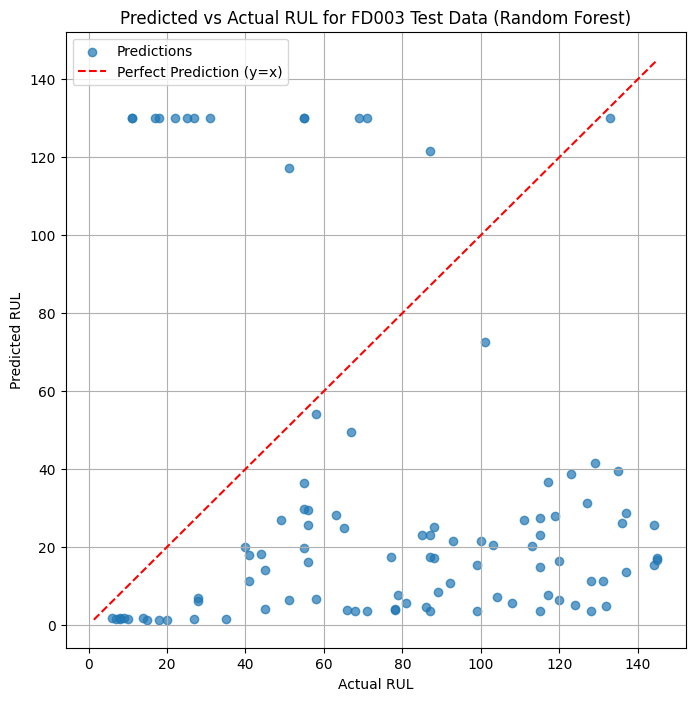

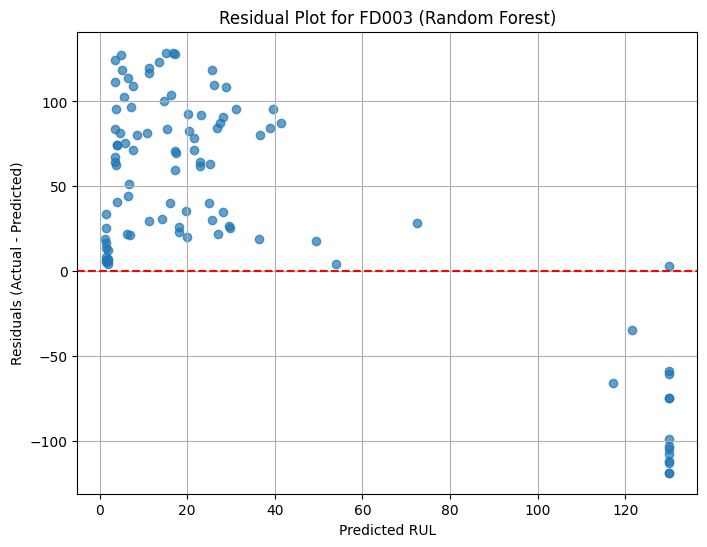

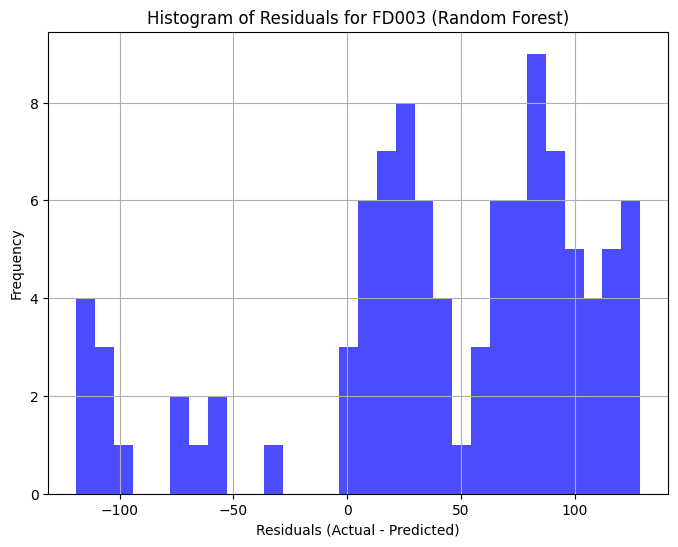

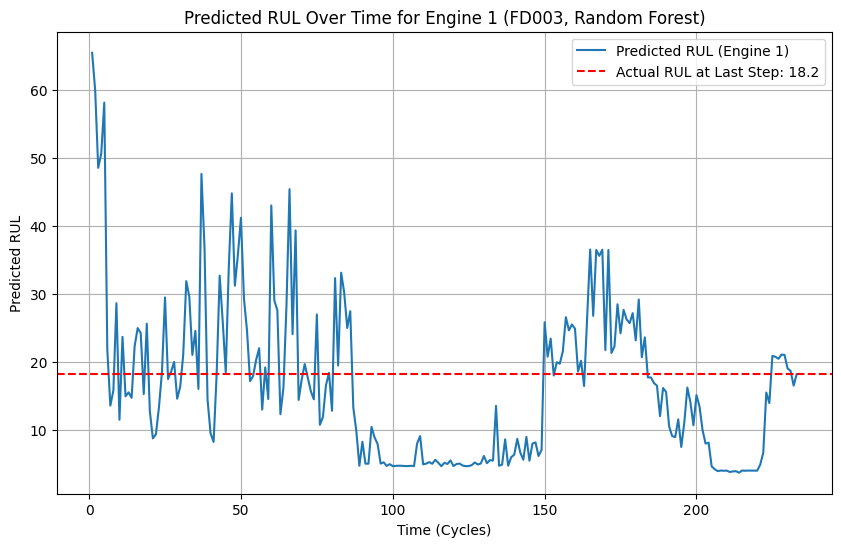

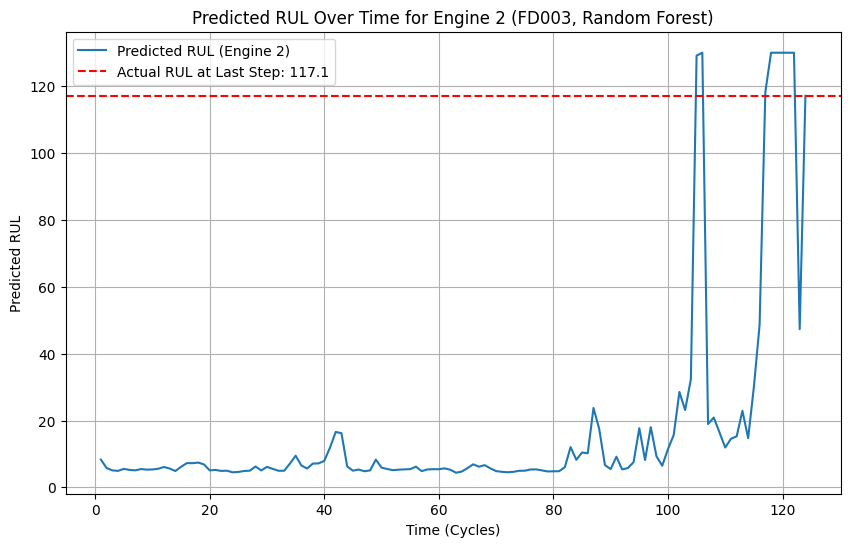

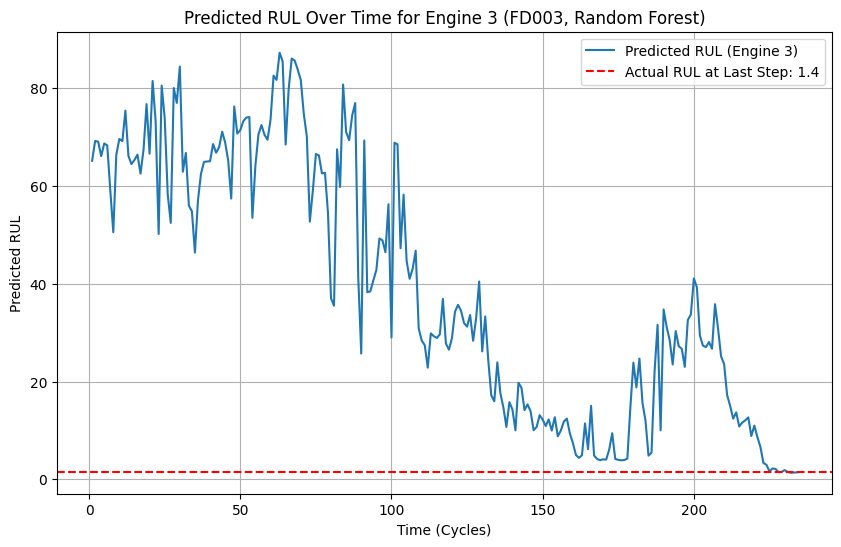

In [3]:
import pandas as pd
import joblib
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error, median_absolute_error, explained_variance_score
import matplotlib.pyplot as plt
import os

# --- Define File Paths ---
TEST_DATA_PATH = r'C:\Users\pandr\hybrid-predictive-maintenance\data\test_stage_predictions\final_stage_test_FD003.csv'
RUL_PATH = r'C:\Users\pandr\hybrid-predictive-maintenance\data\RUL_FD003.txt'
MODEL_PATH = r'C:\Users\pandr\hybrid-predictive-maintenance\models\phase4\rf_regressor_fd003.pkl'
FIGURES_DIR = os.path.join(os.getcwd(), 'figures', 'phase4', 'fd003')

# Create figures directory if it doesn’t exist
os.makedirs(FIGURES_DIR, exist_ok=True)

# --- Regression Phase ---

# Step 1: Load test data
try:
    test_df = pd.read_csv(TEST_DATA_PATH)
    print("Test data loaded successfully.")
except FileNotFoundError:
    print(f"Error: File not found at {TEST_DATA_PATH}. Please check the path and try again.")
    raise

# Step 2: Load the Random Forest model
try:
    loaded_object = joblib.load(MODEL_PATH)
    print("Loaded object type:", type(loaded_object))
    
    # Check if it’s a dictionary (might include model and scaler) or the model directly
    if isinstance(loaded_object, dict):
        print("Loaded dictionary with keys:", list(loaded_object.keys()))
        rf_model = loaded_object['rf']  # Adjust key based on dictionary structure
        scaler = loaded_object.get('scaler')  # Load scaler if present
    else:
        rf_model = loaded_object
        scaler = None  # Assume no scaler if not a dictionary
except FileNotFoundError:
    print(f"Error: Model file not found at {MODEL_PATH}. Please verify the path.")
    raise
except KeyError as e:
    print(f"Error: Missing expected key {e} in the dictionary. Available keys: {list(loaded_object.keys())}")
    raise

# Step 3: Get training features
training_features = rf_model.feature_names_in_
print("Training features:", training_features)

# Step 4: Feature Engineering for Test Data
# Define the list of sensors that need engineered features
sensors = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 
           'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 
           'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']  # Added sensor_10

# Function to compute engineered features for each engine group
def compute_features(group):
    for sensor in sensors:
        # Rolling statistics with window=5
        group[f'{sensor}_rollmin_5'] = group[sensor].rolling(window=5, min_periods=1).min()
        group[f'{sensor}_rollmax_5'] = group[sensor].rolling(window=5, min_periods=1).max()
        group[f'{sensor}_rollstd_5'] = group[sensor].rolling(window=5, min_periods=1).std()
        group[f'{sensor}_rollmean_5'] = group[sensor].rolling(window=5, min_periods=1).mean()  # Added rolling mean
        # Exponential Moving Average (EMA) with span=5
        group[f'{sensor}_ema_5'] = group[sensor].ewm(span=5, adjust=False).mean()
        # Delta (difference between consecutive values)
        group[f'{sensor}_delta'] = group[sensor].diff()
    # Fill NaNs in rolling std and delta
    for sensor in sensors:
        group[f'{sensor}_rollstd_5'] = group[f'{sensor}_rollstd_5'].fillna(0)
        group[f'{sensor}_rollmean_5'] = group[f'{sensor}_rollmean_5'].fillna(0)  # Fill NaNs for rolling mean
        group[f'{sensor}_delta'] = group[f'{sensor}_delta'].fillna(method='ffill').fillna(0)
    # Compute sensor_2_3_ratio, handling division by zero
    group['sensor_2_3_ratio'] = group['sensor_2'] / group['sensor_3'].replace(0, np.nan)
    group['sensor_2_3_ratio'] = group['sensor_2_3_ratio'].fillna(0)
    return group

# Apply feature engineering to test_df, grouped by 'unit'
test_df = test_df.groupby('unit').apply(compute_features, include_groups=False).reset_index()

# Step 5: Verify and select features
# Check for missing or extra features
missing_features = [feat for feat in training_features if feat not in test_df.columns]
extra_features = [feat for feat in test_df.columns if feat not in training_features]
if missing_features:
    raise ValueError(f"Test data is missing features: {missing_features}")
if extra_features:
    print(f"Warning: Dropping extra features from test data: {extra_features}")

# Select and order test data columns to match training features
X_test = test_df[training_features]
# Apply scaling if scaler is available
if scaler is not None:
    X_test_scaled = scaler.transform(X_test)
else:
    X_test_scaled = X_test  # Assume test data is already scaled if no scaler

# Step 6: Predict with the Random Forest model
y_pred = rf_model.predict(X_test_scaled)
# Clip predictions to match training RUL range (if capped during training)
y_pred = np.clip(y_pred, 0, 130)  # Example: cap RUL at 130 cycles
test_df['predicted_RUL'] = y_pred

# Step 7: Extract predicted RUL for the last time step of each engine
last_rows = test_df.groupby('unit').last().reset_index()
predicted_RUL_last = last_rows['predicted_RUL'].values

# Step 8: Load ground truth RUL
try:
    rul_df = pd.read_csv(RUL_PATH, header=None)
    rul_values = rul_df[0].values
except FileNotFoundError:
    print(f"Error: RUL file not found at {RUL_PATH}. Please check the path.")
    raise

# Verify the number of engines matches
if len(last_rows) != len(rul_values):
    raise ValueError(f"Mismatch in number of engines: {len(last_rows)} in test data vs {len(rul_values)} in RUL file.")

# Step 9: Evaluate the model with additional metrics
rmse = np.sqrt(mean_squared_error(rul_values, predicted_RUL_last))
mae = mean_absolute_error(rul_values, predicted_RUL_last)
r2 = r2_score(rul_values, predicted_RUL_last)
mape = mean_absolute_percentage_error(rul_values, predicted_RUL_last)
medae = median_absolute_error(rul_values, predicted_RUL_last)
evs = explained_variance_score(rul_values, predicted_RUL_last)

# Custom scoring function (penalize underestimation more heavily)
def custom_score(y_true, y_pred):
    errors = y_true - y_pred
    penalty = np.where(errors > 0, 1.5 * errors, errors)  # 1.5x penalty for underestimation
    return np.mean(np.abs(penalty))

custom_err = custom_score(rul_values, predicted_RUL_last)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"MAPE: {mape:.4f}")
print(f"Median Absolute Error: {medae:.4f}")
print(f"Explained Variance Score: {evs:.4f}")
print(f"Custom Score (with underestimation penalty): {custom_err:.4f}")

# Step 10: Plot predicted vs actual RUL with a diagonal reference line
plt.figure(figsize=(8, 8))
plt.scatter(rul_values, predicted_RUL_last, alpha=0.7, label='Predictions')
# Add diagonal line (y=x)
min_val = min(min(rul_values), min(predicted_RUL_last))
max_val = max(max(rul_values), max(predicted_RUL_last))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction (y=x)')
plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')
plt.title('Predicted vs Actual RUL for FD003 Test Data (Random Forest)')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(FIGURES_DIR, 'predicted_vs_actual_RUL_rf_fd003.png'))
plt.show()

# Step 11: Residual Plot
residuals = rul_values - predicted_RUL_last
plt.figure(figsize=(8, 6))
plt.scatter(predicted_RUL_last, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted RUL')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot for FD003 (Random Forest)')
plt.grid(True)
plt.savefig(os.path.join(FIGURES_DIR, 'residual_plot_rf_fd003.png'))
plt.show()

# Step 12: Histogram of Residuals
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, alpha=0.7, color='blue')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals for FD003 (Random Forest)')
plt.grid(True)
plt.savefig(os.path.join(FIGURES_DIR, 'residual_histogram_rf_fd003.png'))
plt.show()

# Step 13: Plot Predictions Over Time for a Few Engines
for unit in test_df['unit'].unique()[:3]:  # First 3 engines
    engine_data = test_df[test_df['unit'] == unit]
    plt.figure(figsize=(10, 6))
    plt.plot(engine_data['time'], engine_data['predicted_RUL'], label=f'Predicted RUL (Engine {unit})')
    # Add actual RUL at the last time step
    actual_rul = last_rows[last_rows['unit'] == unit]['predicted_RUL'].iloc[0]
    plt.axhline(y=actual_rul, color='red', linestyle='--', label=f'Actual RUL at Last Step: {actual_rul:.1f}')
    plt.xlabel('Time (Cycles)')
    plt.ylabel('Predicted RUL')
    plt.title(f'Predicted RUL Over Time for Engine {unit} (FD003, Random Forest)')
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(FIGURES_DIR, f'rul_over_time_engine_{unit}_rf_fd003.png'))
    plt.show()